# Forest Fire Risk Prediction
## Baseline Model: Logistic Regression

**Context**: Binary classification — predict whether a forest fire will occur (1) or not (0) on an 8×8 km SAFRAN grid cell for a given day.

**Why Logistic Regression and not Linear Regression?**  
Linear regression can produce probability estimates outside [0, 1]. Logistic regression applies a sigmoid function to guarantee outputs that are interpretable as probabilities. It is the standard linear baseline model for binary classification.

**Class imbalance**: fewer than 0.1% of rows correspond to a fire event. We use `class_weight='balanced'` and evaluate with ROC-AUC and Average Precision — **not accuracy**, which would be misleading here (a model that always predicts 0 would achieve ~99.9% accuracy).

## 0. Imports and Parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)
import joblib

%matplotlib inline

In [2]:
# Weather features (SAFRAN / SIM)
WEATHER_FEATURES = [
    "T",                    # mean temperature
    "FF",                   # wind speed
    "HU",                   # relative humidity
    "PRELIQ",               # liquid precipitation
    "ETP",                  # potential evapotranspiration
    "SWI",                  # soil wetness index
    "SSWI_10J",             # 10-day soil wetness index
    "SSI",                  # solar radiation
    "WG_RACINE",            # root-zone soil moisture
    "T_MOY_7J",             # 7-day mean temperature
    "SIN_SAISON",           # seasonal encoding (sin)
    "COS_SAISON",           # seasonal encoding (cos)
]

# Vegetation features (IGN forest inventory)
VEGETATION_FEATURES = [
    "pct_resineux",             # share of coniferous trees (more flammable)
    "volume_total",             # total wood volume (fuel load proxy)
    "hauteur_moyenne",          # mean tree height
    "age_moyen",                # mean tree age
    "pct_mortalite",            # tree mortality rate
    "pct_probleme_sanitaire",   # share of trees with health issues
]

# Temporal features
TEMPORAL_FEATURES = ["MOIS", "JOUR"]

## 1. Loading and Preparing the Data

In [3]:
df = pd.read_parquet("dataset_final_incendies.parquet")
df.shape
df.head()

,LAMBX,LAMBY,DATE,ANNEE,MOIS,JOUR,MOIS_NUM,T,FF,HU,...,SER,PENTEXP,ASPERITE,ACCES,INCID,NINCID,ANPYR,DPYR,DIST_MAILLE_M,INCENDIE
0,5400,20810,20150427,2015,4,27,4,10.0,3.9,89.8,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
1,5400,20810,20150428,2015,4,28,4,8.0,2.7,66.8,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
2,5400,20810,20150429,2015,4,29,4,8.8,2.5,67.0,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
3,5400,20810,20150430,2015,4,30,4,10.3,3.4,78.7,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
4,5400,20810,20150501,2015,5,1,5,12.6,5.8,98.7,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0


Keep only between may and october where the majority of fire are

In [7]:
df_saison = df[df["MOIS"].between(5, 10)]

In [10]:
df_saison.shape

(18201280, 59)

Undersampling 1/20

In [12]:
feux = df_saison[df_saison["INCENDIE"] == 1]
pas_feux = df_saison[df_saison["INCENDIE"] == 0].sample(n=len(feux) * 20, random_state=42)
df_reduit = pd.concat([feux, pas_feux]).sample(frac=1, random_state=42)

In [14]:
df_reduit.shape

(371721, 59)

In [15]:
TARGET = "INCENDIE"

all_features = WEATHER_FEATURES + VEGETATION_FEATURES + TEMPORAL_FEATURES
print(f"{len(all_features)} features selected: {all_features}")

20 features selected: ['T', 'FF', 'HU', 'PRELIQ', 'ETP', 'SWI', 'SSWI_10J', 'SSI', 'WG_RACINE', 'T_MOY_7J', 'SIN_SAISON', 'COS_SAISON', 'pct_resineux', 'volume_total', 'hauteur_moyenne', 'age_moyen', 'pct_mortalite', 'pct_probleme_sanitaire', 'MOIS', 'JOUR']


Drop rows with NaN only on weather and temporal features (these must be present)

In [17]:
before = len(df_reduit)
df_reduit = df_reduit.dropna(subset=WEATHER_FEATURES + TEMPORAL_FEATURES + [TARGET])
print(f"{before - len(df_reduit):,} rows dropped (NaN on weather/temporal) → {len(df_reduit):,} rows remaining")

0 rows dropped (NaN on weather/temporal) → 371,721 rows remaining


Impute missing vegetation features (most grid cells have no IGN placette nearby)

NaN here means "no IGN forest data on this cell" — we replace with column median

In [18]:
imputer = SimpleImputer(strategy="median")
df_reduit[VEGETATION_FEATURES] = imputer.fit_transform(df_reduit[VEGETATION_FEATURES])

In [20]:
X = df_reduit[all_features].values
y = df_reduit[TARGET].astype(int).values

print(f"\nClass distribution:")
print(f"  Fire     (1): {y.sum():>8,}  ({y.mean()*100:.3f}%)")
print(f"  No fire  (0): {(1-y).sum():>8,}  ({(1-y).mean()*100:.3f}%)")


Class distribution:
  Fire     (1):   17,701  (4.762%)
  No fire  (0):  354,020  (95.238%)


## 2. Train / Test Split

Train on 2015-2023, test on 2024

In [25]:
train_mask = df_reduit["ANNEE"] <= 2023
test_mask  = df_reduit["ANNEE"] == 2024

X_train = df_reduit.loc[train_mask, all_features].values
X_test  = df_reduit.loc[test_mask,  all_features].values
y_train = df_reduit.loc[train_mask, TARGET].astype(int).values
y_test  = df_reduit.loc[test_mask,  TARGET].astype(int).values

print(f"Train (2015-2023): {len(X_train):,} rows  |  Fire: {y_train.sum():,}")
print(f"Test  (2024)     : {len(X_test):,} rows   |  Fire: {y_test.sum():,}")

Train (2015-2023): 335,137 rows  |  Fire: 16,843
Test  (2024)     : 36,584 rows   |  Fire: 858


## 3. Feature Scaling

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 4. Model Training

`class_weight='balanced'` automatically adjusts weights so that the rare fire events are given as much importance as the dominant no-fire class. Without this, the model would simply learn to always predict 0.

In [ ]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
)
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

## 5. Evaluation

- **ROC-AUC**: overall ability to separate the two classes (1.0 = perfect, 0.5 = random)  
- **Average Precision**: summary of the Precision-Recall curve, robust to class imbalance  
- **Classification report**: precision, recall and F1 per class at the chosen threshold

In [28]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred  = (y_proba >= 0.3).astype(int)

roc_auc       = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

print(f"ROC-AUC           : {roc_auc:.4f}  (1.0 = perfect, 0.5 = random)")
print(f"Average Precision  : {avg_precision:.4f}  (robust to class imbalance)")
print(f"Decision threshold : {0.3}")
print()
print(classification_report(y_test, y_pred, target_names=["No fire", "Fire"]))

ROC-AUC           : 0.9035  (1.0 = perfect, 0.5 = random)
Average Precision  : 0.2484  (robust to class imbalance)
Decision threshold : 0.3

              precision    recall  f1-score   support

     No fire       1.00      0.82      0.90     35726
        Fire       0.10      0.86      0.19       858

    accuracy                           0.82     36584
   macro avg       0.55      0.84      0.54     36584
weighted avg       0.97      0.82      0.88     36584



It correctly flags 86% of fire days, at the cost of 0.10 precision. Out of all predicted fires, only 10% are real fires. This sounds bad but is expected with 2.3% positives in test.

## 6. Feature Importance (Coefficients)

A **positive** coefficient increases the predicted fire probability; a **negative** one decreases it. Since all features are standardized, the absolute values are directly comparable across features.

In [29]:
coefficients = pd.Series(
    model.coef_[0], index=all_features
).sort_values(key=abs, ascending=False)

coefficients.to_frame("Coefficient")

,Coefficient
COS_SAISON,0.922114
T_MOY_7J,0.759869
HU,-0.641390
MOIS,-0.595744
WG_RACINE,-0.573950
SWI,-0.516086
SIN_SAISON,0.361939
hauteur_moyenne,-0.326165
ETP,0.273998
pct_resineux,0.215601


## 7. Visualizations

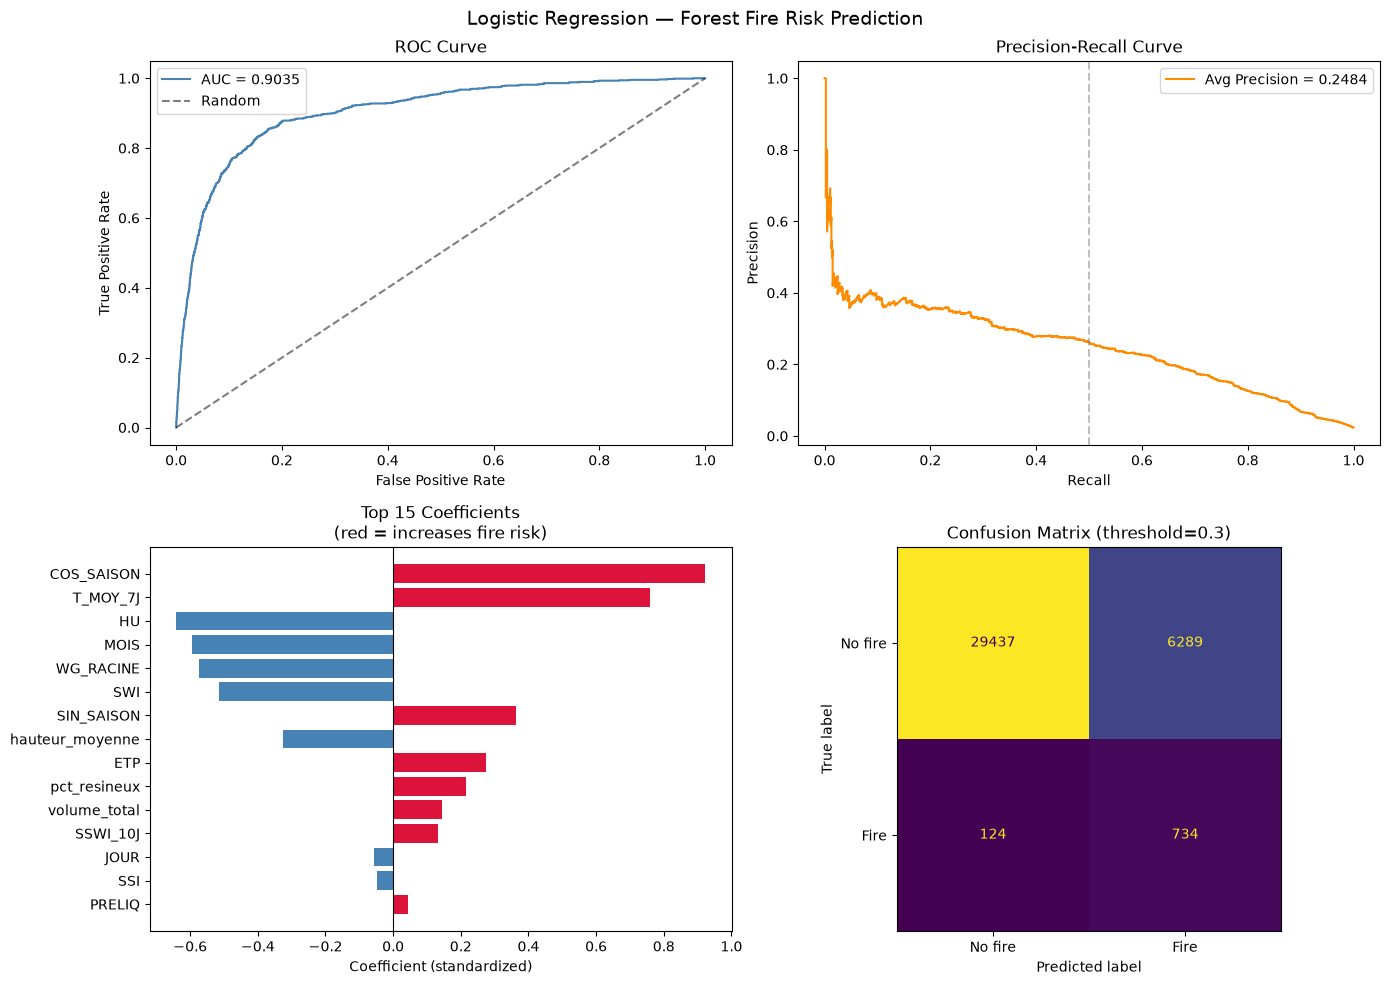

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Logistic Regression — Forest Fire Risk Prediction", fontsize=14)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, color="steelblue", label=f"AUC = {roc_auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# --- Precision-Recall Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(recall_vals, precision_vals, color="darkorange",
                label=f"Avg Precision = {avg_precision:.4f}")
axes[0, 1].axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("Precision-Recall Curve")
axes[0, 1].legend()

# --- Top 15 Coefficients ---
top15  = coefficients.head(15)
colors = ["crimson" if v > 0 else "steelblue" for v in top15.values]
axes[1, 0].barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
axes[1, 0].axvline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("Top 15 Coefficients\n(red = increases fire risk)")
axes[1, 0].set_xlabel("Coefficient (standardized)")

# --- Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No fire", "Fire"],
    ax=axes[1, 1], colorbar=False,
)
axes[1, 1].set_title(f"Confusion Matrix (threshold={0.3})")

plt.tight_layout()
plt.show()